# 🎗️ Breast Cancer Classification using Support Vector Machines (SVM)
**Objective:** Classify breast cancer tumors as either Malignant (M) or Benign (B) based on cell nucleus features extracted from digitized images. We will utilize a **Support Vector Machine (SVM)** classifier, which is highly effective in high-dimensional spaces like this dataset.

In [3]:
# 1. Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

print(" Libraries Imported Successfully!")

 Libraries Imported Successfully!


---
### 📂 Step 1: Load Data & Clean
We will drop irrelevant columns like `id` and the empty `Unnamed: 32` column. Since this is a critical medical dataset, we want to retain as much valid signal as possible.

In [4]:
# Load Dataset 
# (Make sure the CSV name matches exactly what you uploaded)
df = pd.read_csv('Cancer_Data.csv')

# Drop irrelevant columns (ID doesn't predict cancer, Unnamed is empty)
columns_to_drop = ['id', 'Unnamed: 32']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head(3))

Cleaned Dataset Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


---
### 📊 Step 2: Exploratory Data Analysis (EDA)
Let's see the distribution of the target variable (`diagnosis`) and the relationship between the tumor's radius and texture.

C:\Users\ahmed\AppData\Local\Temp\ipykernel_10688\3446827265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette=['blue', 'red'])


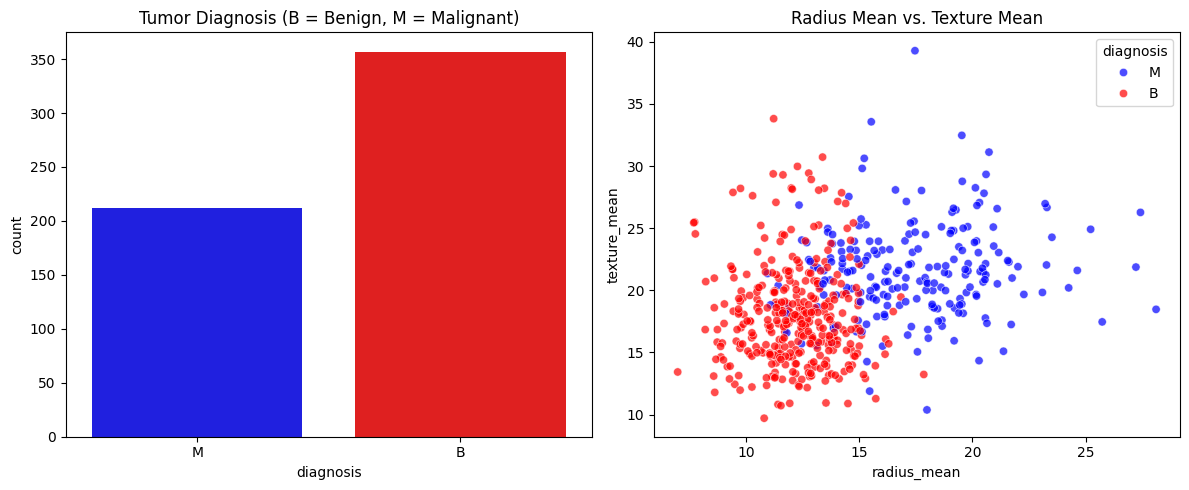

 Observation: Malignant tumors generally have a higher radius and texture mean compared to Benign tumors.


In [5]:
plt.figure(figsize=(12, 5))

# Plot 1: Target Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='diagnosis', palette=['blue', 'red'])
plt.title('Tumor Diagnosis (B = Benign, M = Malignant)')

# Plot 2: Radius vs Texture colored by Diagnosis
plt.subplot(1, 2, 2)
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df, palette=['blue', 'red'], alpha=0.7)
plt.title('Radius Mean vs. Texture Mean')

plt.tight_layout()
plt.show()

print(" Observation: Malignant tumors generally have a higher radius and texture mean compared to Benign tumors.")

---
### ✂️ Step 3: Target Encoding, Feature Separation & Train-Test Split

In [6]:
# Separate Features (X) and Target (y)
X = df.drop('diagnosis', axis=1)
y_raw = df['diagnosis']

# Encode the Target variable: B -> 0, M -> 1
# This is necessary for SVM and calculating the ROC curve
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Split Data (80% Train, 20% Test) using Stratify to maintain the B/M ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Features Shape: {X_train.shape}")

Training Features Shape: (455, 30)


---
### 🏗️ Step 4: Build the SVM Pipeline
**Critical Concept:** SVM algorithms attempt to find a hyperplane that maximizes the margin between classes. If features are not scaled properly, features with larger ranges will dominate the calculation. `StandardScaler` is absolutely mandatory here. We will use a linear kernel for this implementation.

In [7]:
# Build the Pipeline
svm_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), # Standardize features to mean 0, variance 1
    ('classifier', SVC(kernel='linear', probability=True, random_state=42)) # SVM Model
])

print(" SVM Classification Pipeline Built Successfully")

 SVM Classification Pipeline Built Successfully


---
### 🚀 Step 5: Train, Evaluate, and Visualize Performance
For medical models, false negatives (missing a cancer diagnosis) are highly dangerous. We will analyze the Confusion Matrix and the **ROC Curve (Receiver Operating Characteristic)** to evaluate performance.

🏆 SVM Model Accuracy: 96.49%

📄 Classification Report (0 = Benign, 1 = Malignant):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



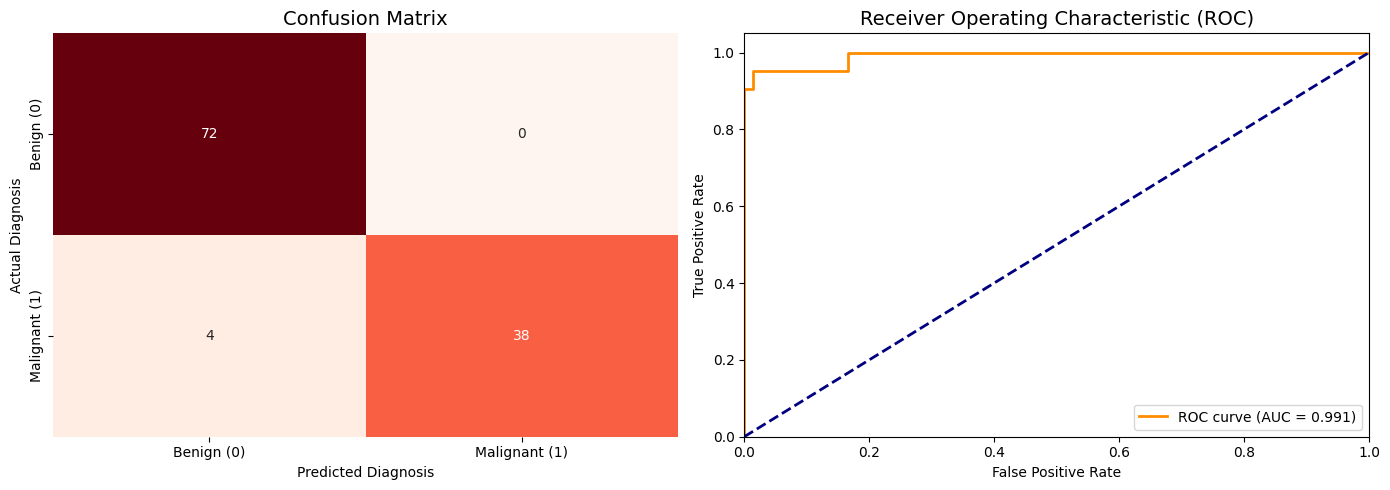

In [8]:
# Train the Pipeline
svm_pipeline.fit(X_train, y_train)

# Predict on Test Data
y_pred = svm_pipeline.predict(X_test)
y_prob = svm_pipeline.predict_proba(X_test)[:, 1] # Get probabilities for ROC curve

# 1. Evaluation Metrics
print(f"🏆 SVM Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("📄 Classification Report (0 = Benign, 1 = Malignant):")
print(classification_report(y_test, y_pred))

# ==========================================
# 📈 Visualizations: Confusion Matrix & ROC Curve
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax[0],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
ax[0].set_title('Confusion Matrix', fontsize=14)
ax[0].set_xlabel('Predicted Diagnosis')
ax[0].set_ylabel('Actual Diagnosis')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()